In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from tqdm import tqdm
from matplotlib.patches import Patch

In [2]:
def get_number_pocket_triplets(df):
    return len(set(tuple(sorted([i, j, k])) for i, j, k in zip(df['pocket1'], df['pocket2'], df['pocket3'])))

def get_number_protein_triplets(df):
    return len(set(tuple(sorted([i, j, k])) for i, j, k in zip(df['protein1'], df['protein2'], df['protein3'])))

In [3]:
#####################################################
#####################################################
###############------ PHASE 1 ------#################
#####################################################
#####################################################

In [4]:
###########  TRIPLETS  ###########

In [5]:
ALL_RESULTS_TRIPLETS = pd.read_csv("../processed/protein_prioritization/triplets.tsv", sep='\t', low_memory=False)
ALL_RESULTS_TRIPLETS["interpro_pocket1"] = ALL_RESULTS_TRIPLETS["interpro_pocket1"].fillna("").astype(str)
ALL_RESULTS_TRIPLETS["interpro_pocket2"] = ALL_RESULTS_TRIPLETS["interpro_pocket2"].fillna("").astype(str)
ALL_RESULTS_TRIPLETS["interpro_pocket3"] = ALL_RESULTS_TRIPLETS["interpro_pocket3"].fillna("").astype(str)

proteins = sorted(set(ALL_RESULTS_TRIPLETS['protein1']).union(set(ALL_RESULTS_TRIPLETS['protein2'])).union(set(ALL_RESULTS_TRIPLETS['protein3'])))

In [6]:
RMSD_CUT_OFF = 10
SEQID_CUT_OFF = 30

In [8]:
ALL_RESULTS_TRIPLETS

,protein1,pocket1,interpro_pocket1,protein2,pocket2,interpro_pocket2,protein3,pocket3,interpro_pocket3,dist_A,...,SEQ_ID_NW_C,Dist PDB 1,Dist PDB 2,Dist PDB 3,Dist Alphafill 1,Dist AlphaFill 2,Dist Alphafill 3,P2Rank score 1,P2Rank score 2,P2Rank score 3
0,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold2_P9WFT3_model_0_pocket_1,Catalytic Domain (ATP Binding Site),0.235,...,25.6410,NaN,NaN,NaN,1.202,0.683,0.721,38.06,29.17,13.69
1,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold2_P9WFT3_model_0_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.235,...,25.6410,NaN,NaN,NaN,1.202,0.683,3.102,38.06,29.17,4.80
2,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_0_pocket_1,Catalytic Domain (ATP Binding Site),0.235,...,25.6410,NaN,NaN,NaN,1.202,0.683,0.414,38.06,29.17,10.19
3,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_2_pocket_2,Catalytic Domain (ATP Binding Site),0.235,...,25.6410,NaN,NaN,NaN,1.202,0.683,0.597,38.06,29.17,9.31
4,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_3_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.235,...,25.6410,NaN,NaN,NaN,1.202,0.683,2.728,38.06,29.17,1.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499253,P9WFW7,swissmodel_P9WFW7_model_0_pocket_2,Editing Domain;Other too broad/unspecified fun...,P9WN61,swissmodel_P9WN61_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WQA1,chai1_P9WQA1_model_1_pocket_1,,0.192,...,26.2774,NaN,NaN,NaN,7.870,11.979,8.126,15.99,5.38,7.52
2499254,P9WFW7,swissmodel_P9WFW7_model_0_pocket_2,Editing Domain;Other too broad/unspecified fun...,P9WN61,swissmodel_P9WN61_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WQA1,chai1_P9WQA1_model_2_pocket_1,,0.192,...,26.2774,NaN,NaN,NaN,7.870,11.979,8.378,15.99,5.38,7.87
2499255,P9WFW7,swissmodel_P9WFW7_model_0_pocket_2,Editing Domain;Other too broad/unspecified fun...,P9WN61,swissmodel_P9WN61_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WQA1,chai1_P9WQA1_model_3_pocket_1,,0.192,...,26.2774,NaN,NaN,NaN,7.870,11.979,10.258,15.99,5.38,7.94
2499256,P9WFW7,swissmodel_P9WFW7_model_0_pocket_2,Editing Domain;Other too broad/unspecified fun...,P9WN61,swissmodel_P9WN61_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WQA1,chai1_P9WQA1_model_4_pocket_2,,0.192,...,26.2774,NaN,NaN,NaN,7.870,11.979,9.831,15.99,5.38,8.42


In [9]:
# CATALYTIC COUNTS
CATALYTIC_COUNTS = []
for i,j,k in zip(ALL_RESULTS_TRIPLETS['interpro_pocket1'], ALL_RESULTS_TRIPLETS['interpro_pocket2'], ALL_RESULTS_TRIPLETS['interpro_pocket3']):
    counts = []
    for interpro in [i,k,j]:
        if "Catalytic Domain (ATP Binding Site)" in interpro:
            counts.append(1)
        else:
            counts.append(0)
    CATALYTIC_COUNTS.append(sum(counts))
ALL_RESULTS_TRIPLETS['catalytic_counts'] = CATALYTIC_COUNTS


# GLOBAL SIMILARITY
GLOBAL_SIMILARITY = []
for seqidA, seqidB, seqidC, rmsdA, rmsdB, rmsdC in zip(ALL_RESULTS_TRIPLETS['SEQ_ID_NW_A'], ALL_RESULTS_TRIPLETS['SEQ_ID_NW_B'], ALL_RESULTS_TRIPLETS['SEQ_ID_NW_C'], 
                                                    ALL_RESULTS_TRIPLETS['RMSD_A'], ALL_RESULTS_TRIPLETS['RMSD_B'], ALL_RESULTS_TRIPLETS['RMSD_C']):
    counts = []
    if seqidA > SEQID_CUT_OFF or rmsdA < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    if seqidB > SEQID_CUT_OFF or rmsdB < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    if seqidC > SEQID_CUT_OFF or rmsdC < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    GLOBAL_SIMILARITY.append(sum(counts))
ALL_RESULTS_TRIPLETS['global_similarity'] = GLOBAL_SIMILARITY

In [10]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_ALL = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 2,078[15]
GS 0 -- CAT 1 -- 33,061[115]
GS 0 -- CAT 2 -- 86,221[159]
GS 1 -- CAT 0 -- 12,987[65]
GS 1 -- CAT 1 -- 121,836[315]
GS 1 -- CAT 2 -- 375,813[421]
GS 2 -- CAT 0 -- 89,639[153]
GS 2 -- CAT 1 -- 532,681[546]
GS 2 -- CAT 2 -- 1,244,942[728]


In [11]:
sum(TOTAL)

2499258

In [61]:
ALL_RESULTS_TRIPLETS_POCKETVEC_017 = ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['dist_A'] < 0.17) & 
                                                          (ALL_RESULTS_TRIPLETS['dist_B'] < 0.17) & 
                                                          (ALL_RESULTS_TRIPLETS['dist_C'] < 0.17)].reset_index(drop=True)

ALL_RESULTS_TRIPLETS_POCKETVEC_017.to_csv("../processed/protein_prioritization/triplets_filtered.tsv", sep='\t', index=False)

In [62]:
len(ALL_RESULTS_TRIPLETS_POCKETVEC_017)

3880

In [14]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_017 = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 0[0]
GS 0 -- CAT 1 -- 16[7]
GS 0 -- CAT 2 -- 45[20]
GS 1 -- CAT 0 -- 4[4]
GS 1 -- CAT 1 -- 44[21]
GS 1 -- CAT 2 -- 560[84]
GS 2 -- CAT 0 -- 23[14]
GS 2 -- CAT 1 -- 241[93]
GS 2 -- CAT 2 -- 2,947[217]


In [15]:
sum(TOTAL)

3880

In [16]:
ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE = ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['dist_A'] < 0.17) & 
                                                               (ALL_RESULTS_TRIPLETS['dist_B'] < 0.17) & 
                                                               (ALL_RESULTS_TRIPLETS['dist_C'] < 0.17)].reset_index(drop=True)

ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_A'] < 0.13) |
                                                                                   (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_B'] < 0.13) |
                                                                                   (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['dist_C'] < 0.13)].reset_index(drop=True)

In [17]:
len(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE)

375

In [18]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] == GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 0
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 1
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] == CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS, CAT = 2, 2
COND = (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['global_similarity'] >= GS) & (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_triplets(COND):,}[{get_number_protein_triplets(COND)}]")
TOTAL.append(get_number_pocket_triplets(COND))
counter = Counter(COND['protein1'].tolist() + COND['protein2'].tolist() + COND['protein3'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 0[0]
GS 0 -- CAT 1 -- 1[1]
GS 0 -- CAT 2 -- 3[2]
GS 1 -- CAT 0 -- 0[0]
GS 1 -- CAT 1 -- 3[2]
GS 1 -- CAT 2 -- 75[24]
GS 2 -- CAT 0 -- 0[0]
GS 2 -- CAT 1 -- 11[10]
GS 2 -- CAT 2 -- 282[76]


In [20]:
sum(TOTAL)

375

In [21]:
#####################################################
#####################################################
###############------ PHASE 2 ------#################
#####################################################
#####################################################

In [22]:
#####################################################
#####################################################
###############------ PHASE 3 ------#################
#####################################################
#####################################################

In [39]:
###########  TRIPLETS  ###########

In [40]:
ERSILIA_COLORS = {(0,0): '#50285A', 
                  (0,1): '#FAD782', 
                  (0,2): '#FAA08B', 
                  (1,0): '#DC9FDC', 
                  (1,1): '#AA96FA', 
                  (1,2): '#8DC7FA', 
                  (2,0): '#BEE6B4', 
                  (2,1): '#D2D2D2', 
                  (2,2): 'w'}

inds = sorted(ERSILIA_COLORS)

In [41]:
### ALL RESULTS ###

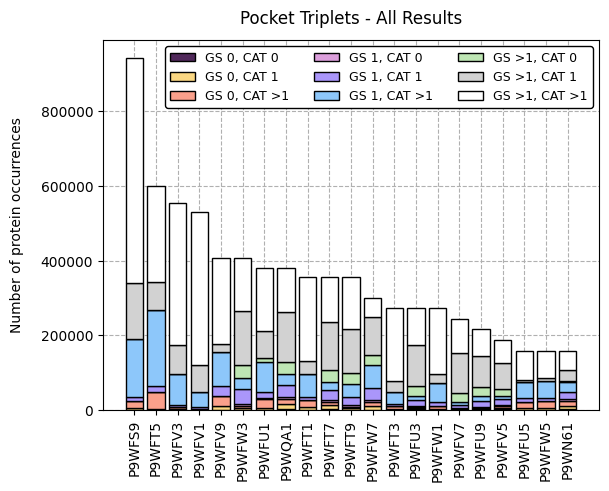

In [42]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_ALL, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_ALL[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_ALL[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All Results", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [43]:
### POCKETVEC < 0.17 ###

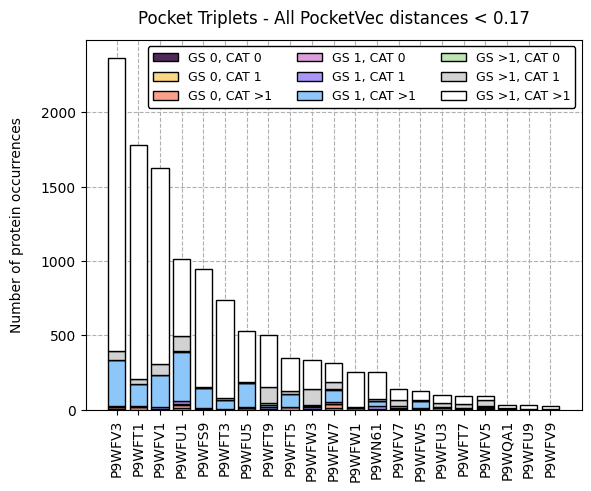

In [44]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_017, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_017[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [45]:
### POCKETVEC < 0.17 & MORE ###

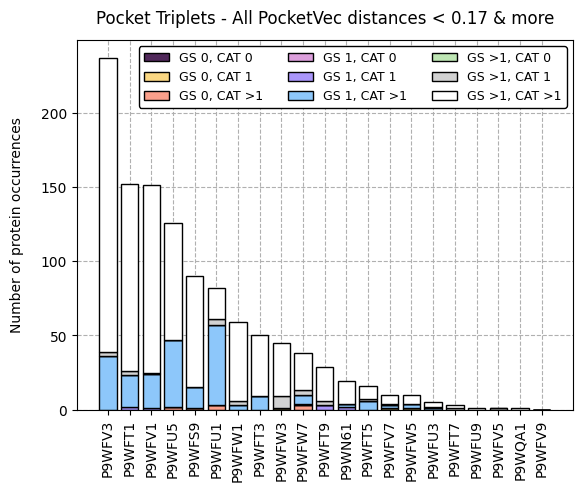

In [46]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0] if ind[0] != 2 else '>1'}, CAT {ind[1] if ind[1] != 2 else '>1'}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017_MORE[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Triplets - All PocketVec distances < 0.17 & more", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=3, prop={'size': 9})
plt.show()

In [47]:
### NOW FROM THE DOMAIN PERSPECTIVE ... ###

In [48]:
ERSILIA_COLORS = ['#50285A', '#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4', '#D2D2D2'][1:]

In [49]:
### ALL RESULTS ###

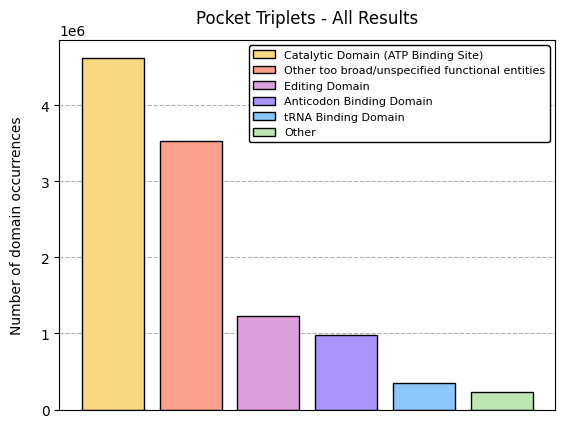

In [50]:
interpro_domains = ALL_RESULTS_TRIPLETS['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All Results", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [51]:
### POCKETVEC < 0.17 ###

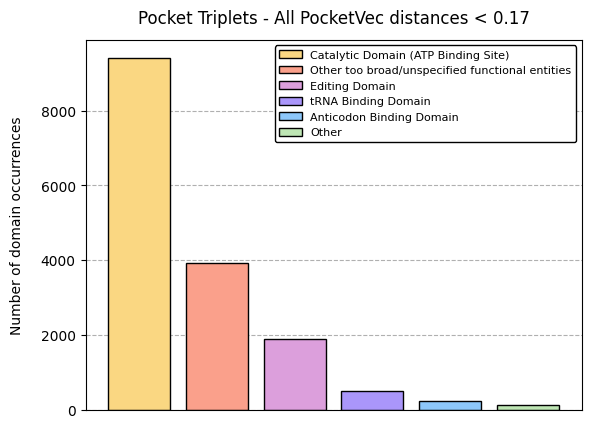

In [52]:
interpro_domains = ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [53]:
### POCKETVEC < 0.17 & MORE ###

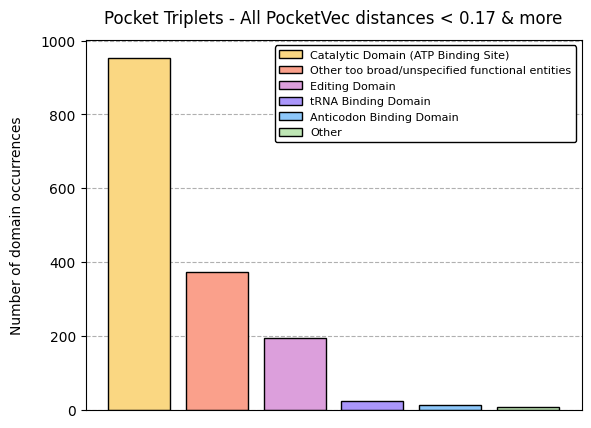

In [54]:
interpro_domains = ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket3'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Triplets - All PocketVec distances < 0.17 & more", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [55]:
### NOW FROM THE DOMAIN/PROTEIN PERSPECTIVE ... ###

In [56]:
ERSILIA_COLORS = ['#50285A', '#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4', '#D2D2D2'][1:]

cc_colors = {
            'A': ['#EA5A49', '#EE7B6D', '#F7BDB6'],
            'B': ['#B16BA8', '#C189B9', '#D0A6CB'],
            'C': ['#5A72B5', '#7B8EC4', '#9CAAD3'],
            'D': ['#7CAF2A', '#96BF55', '#B0CF7F'],
            'E': ['#F39426', '#F5A951', '#F8BF7D'],
            'Z': ['#000000', '#666666', '#999999']}

In [57]:
ALL_RESULTS_TRIPLETS.head()

,protein1,pocket1,interpro_pocket1,protein2,pocket2,interpro_pocket2,protein3,pocket3,interpro_pocket3,dist_A,...,Dist PDB 2,Dist PDB 3,Dist Alphafill 1,Dist AlphaFill 2,Dist Alphafill 3,P2Rank score 1,P2Rank score 2,P2Rank score 3,catalytic_counts,global_similarity
0,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold2_P9WFT3_model_0_pocket_1,Catalytic Domain (ATP Binding Site),0.235,...,NaN,NaN,1.202,0.683,0.721,38.06,29.17,13.69,3,3
1,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold2_P9WFT3_model_0_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.235,...,NaN,NaN,1.202,0.683,3.102,38.06,29.17,4.80,3,3
2,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_0_pocket_1,Catalytic Domain (ATP Binding Site),0.235,...,NaN,NaN,1.202,0.683,0.414,38.06,29.17,10.19,3,3
3,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_2_pocket_2,Catalytic Domain (ATP Binding Site),0.235,...,NaN,NaN,1.202,0.683,0.597,38.06,29.17,9.31,3,3
4,P9WFS9,alphafold2_P9WFS9_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT1,alphafold2_P9WFT1_model_0_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFT3,alphafold3_P9WFT3_model_3_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.235,...,NaN,NaN,1.202,0.683,2.728,38.06,29.17,1.26,3,3


In [58]:
domains = ALL_RESULTS_TRIPLETS['interpro_pocket1'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket2'].tolist() + ALL_RESULTS_TRIPLETS['interpro_pocket3'].tolist()
domains = set([j for i in domains for j in i.split(";") if j != ""])
proteins = set(ALL_RESULTS_TRIPLETS['protein1'].tolist() + ALL_RESULTS_TRIPLETS['protein2'].tolist())

# ALL RESULTS
protein_to_domain_counts_ALL_RESULTS = {i: {j: 0 for j in domains} for i in proteins}
for protein in tqdm(proteins):
    for domain in domains:
        protein_to_domain_counts_ALL_RESULTS[protein][domain] = len(ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['protein1'] == protein) & 
                                                                                      (ALL_RESULTS_TRIPLETS['interpro_pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_ALL_RESULTS[protein][domain] += len(ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['protein2'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS['interpro_pocket2'].str.contains(domain, regex=False))])
        protein_to_domain_counts_ALL_RESULTS[protein][domain] += len(ALL_RESULTS_TRIPLETS[(ALL_RESULTS_TRIPLETS['protein3'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS['interpro_pocket3'].str.contains(domain, regex=False))])
        
# POCKETVEC < 0.17
protein_to_domain_counts_POCKETVEC_017 = {i: {j: 0 for j in domains} for i in proteins}
for protein in tqdm(proteins):
    for domain in domains:
        protein_to_domain_counts_POCKETVEC_017[protein][domain] = len(ALL_RESULTS_TRIPLETS_POCKETVEC_017[(ALL_RESULTS_TRIPLETS_POCKETVEC_017['protein1'] == protein) & 
                                                                                      (ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_017[protein][domain] += len(ALL_RESULTS_TRIPLETS_POCKETVEC_017[(ALL_RESULTS_TRIPLETS_POCKETVEC_017['protein2'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket2'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_017[protein][domain] += len(ALL_RESULTS_TRIPLETS_POCKETVEC_017[(ALL_RESULTS_TRIPLETS_POCKETVEC_017['protein3'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS_POCKETVEC_017['interpro_pocket3'].str.contains(domain, regex=False))])

# POCKETVEC < 0.17 & MORE
protein_to_domain_counts_POCKETVEC_017_MORE = {i: {j: 0 for j in domains} for i in proteins}
for protein in tqdm(proteins):
    for domain in domains:
        protein_to_domain_counts_POCKETVEC_017_MORE[protein][domain] = len(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['protein1'] == protein) & 
                                                                                      (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_017_MORE[protein][domain] += len(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['protein2'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket2'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_017_MORE[protein][domain] += len(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE[(ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['protein3'] == protein) & 
                                                                                       (ALL_RESULTS_TRIPLETS_POCKETVEC_017_MORE['interpro_pocket3'].str.contains(domain, regex=False))])

100%|██████████| 20/20 [00:00<00:00, 204.27it/s]


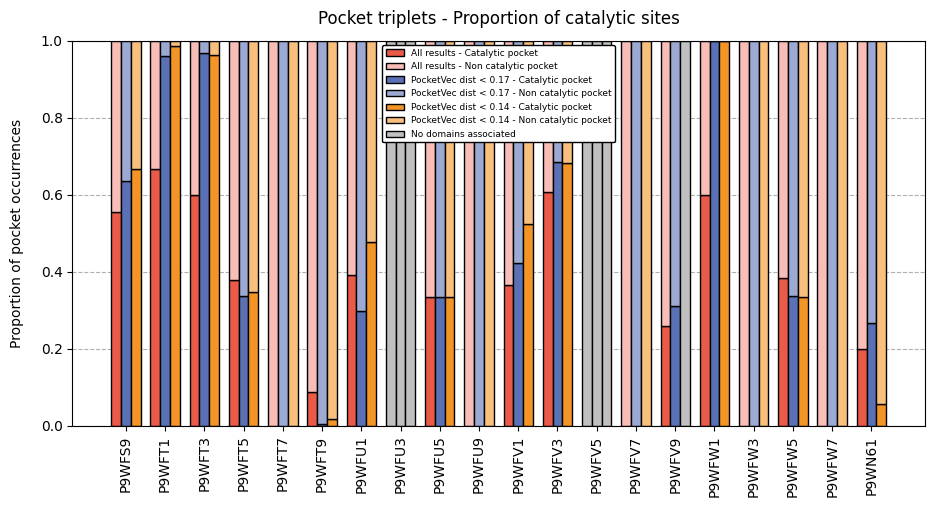

In [60]:
plt.figure(figsize=(11, 5))
plt.title("Pocket triplets - Proportion of catalytic sites", pad=12)

for c1, protein in enumerate(sorted(proteins)):

    w = 0.25

    # All results
    total = sum(protein_to_domain_counts_ALL_RESULTS[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_ALL_RESULTS[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1-w, prop_cat, width=w, color=cc_colors['A'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1-w, 1-prop_cat, width=w, color=cc_colors['A'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1-w, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

    # PocketVec < 0.17
    total = sum(protein_to_domain_counts_POCKETVEC_017[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_POCKETVEC_017[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1, prop_cat, width=w, color=cc_colors['C'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1, 1-prop_cat, width=w, color=cc_colors['C'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

    # PocketVec < 0.17
    total = sum(protein_to_domain_counts_POCKETVEC_017_MORE[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_POCKETVEC_017_MORE[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1+w, prop_cat, width=w, color=cc_colors['E'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1+w, 1-prop_cat, width=w, color=cc_colors['E'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1+w, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

plt.ylabel('Proportion of pocket occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], sorted(proteins), rotation=90)
plt.grid(linestyle='--', zorder=-2)

legend_elements = [
    Patch(facecolor=cc_colors['A'][0], edgecolor='k', label='All results - Catalytic pocket'),
    Patch(facecolor=cc_colors['A'][2], edgecolor='k', label='All results - Non catalytic pocket'),
    Patch(facecolor=cc_colors['C'][0], edgecolor='k', label='PocketVec dist < 0.17 - Catalytic pocket'),
    Patch(facecolor=cc_colors['C'][2], edgecolor='k', label='PocketVec dist < 0.17 - Non catalytic pocket'),
    Patch(facecolor=cc_colors['E'][0], edgecolor='k', label='PocketVec dist < 0.14 - Catalytic pocket'),
    Patch(facecolor=cc_colors['E'][2], edgecolor='k', label='PocketVec dist < 0.14 - Non catalytic pocket'),
    Patch(facecolor="silver", edgecolor='k', label='No domains associated')
]

plt.legend(handles=legend_elements, loc='upper center', framealpha=1, edgecolor='k', prop={'size': 6.5}, ncols=1)
plt.show()